In [1]:
import numpy as np
import gdsfactory as gf


def rounded_rect_points(width, height, radius, n=40):
    w = width / 2
    h = height / 2
    r = radius

    centers = [
        (w - r, h - r),
        (-w + r, h - r),
        (-w + r, -h + r),
        (w - r, -h + r),
    ]

    angle_ranges = [
        (0, 90),
        (90, 180),
        (180, 270),
        (270, 360),
    ]

    points = []

    for (cx, cy), (a1, a2) in zip(centers, angle_ranges):
        theta = np.linspace(np.deg2rad(a1), np.deg2rad(a2), n)

        for t in theta:
            points.append(
                (
                    cx + r * np.cos(t),
                    cy + r * np.sin(t),
                )
            )

    return points

def add_text(
    c: gf.Component,
    square_size: float,
    beam_width: float,
    layer=(1, 0),
):
    """Add parameter label under the pattern."""

    label = gf.components.text(
        text=f"L={square_size} W={beam_width}",
        size=40,
        layer=layer,
    )

    label_ref = c << label

    # 放在图案正下方，水平居中
    label_ref.move(
        (
            square_size / 2 - label.xsize / 2,
            -150,
        )
    )




In [2]:
# make unit，画一个 和 make_pattern，旋转成四个
@gf.cell
def make_unit(
    outer_width,
    outer_height,
    inner_width,
    inner_height,
    beam_width,
    top_beam_length,
    overlap,
    layer=(1, 0),
):
    bottom_beam_length = 2 * top_beam_length

    outer = gf.Component()

    outer.add_polygon(
        rounded_rect_points(
            width=outer_width,
            height=outer_height,
            radius=outer_height / 2,
        ),
        layer=layer,
    )

    top = outer << gf.components.rectangle(
        size=(beam_width, top_beam_length),
        layer=layer,
    )
    top.move(
        (
            -beam_width / 2,
            outer_height / 2 - overlap,
        )
    )

    bottom = outer << gf.components.rectangle(
        size=(beam_width, bottom_beam_length),
        layer=layer,
    )
    bottom.move(
        (
            -beam_width / 2,
            -outer_height / 2 - bottom_beam_length + overlap,
        )
    )

    inner = gf.Component()
    inner.add_polygon(
        rounded_rect_points(
            width=inner_width,
            height=inner_height,
            radius=inner_height / 2,
        ),
        layer=layer,
    )

    unit = gf.boolean(
        A=outer,
        B=inner,
        operation="not",
        layer=layer,
    )

    c = gf.Component()
    c << unit
    return c


@gf.cell
def make_pattern(
    square_size=2100,
    beam_width=35,
    layer=(1, 0),
    center_rect_size=100,
):
    c = gf.Component()

    outer_height = 20 * beam_width
    outer_width = 3.0 * outer_height

    ring_width = 0.75 * beam_width

    inner_width = outer_width - 2 * ring_width
    inner_height = outer_height - 2 * ring_width

    overlap = 0.15 * beam_width

    top_beam_length = (
        square_size / 2 - outer_height + 2 * overlap
    ) / 3

    bottom_beam_length = 2 * top_beam_length

    if top_beam_length <= 0:
        raise ValueError(
            "square_size is too small. Increase square_size or reduce beam_width."
        )

    unit = make_unit(
        outer_width=outer_width,
        outer_height=outer_height,
        inner_width=inner_width,
        inner_height=inner_height,
        beam_width=beam_width,
        top_beam_length=top_beam_length,
        overlap=overlap,
        layer=layer,
    )

    bottom_center = (
        0,
        -outer_height / 2 - bottom_beam_length + overlap,
    )

    for angle in [0, 90, 180, 270]:
        ref = c << unit
        ref.move(
            origin=bottom_center,
            destination=(0, 0),
        )
        ref.rotate(
            angle,
            center=(0, 0),
        )

    # 中间矩形
    center_rect = c << gf.components.rectangle(
        size=(center_rect_size, center_rect_size),
        layer=layer,
    )
    center_rect.move(
        (
            -center_rect_size / 2,
            -center_rect_size / 2,
        )
    )

    return c




In [3]:
# make_final_structure，挖掉pattern，添加其他层
@gf.cell
def make_final_structure(
    square_size=2100,
    beam_width=35,
    layer=(1, 0),
    center_rect_size=100,
):
    """
    Layer 1:
        square - pattern

    Text:
        B1 under Layer 1 pattern

    Layer 3:
        backside_koh_etch0 rectangle
        size = square_size + 2 * 371.72
        centered with Layer 1 pattern
    """

    c = gf.Component()

    # ============================================================
    # 1. Layer 1: square - pattern
    # ============================================================
    pattern = make_pattern(
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
        center_rect_size=center_rect_size,
    )

    square = gf.Component()
    square_ref = square << gf.components.rectangle(
        size=(square_size, square_size),
        layer=layer,
    )
    square_ref.move(
        (
            -square_size / 2,
            -square_size / 2,
        )
    )

    structure = gf.boolean(
        A=square,
        B=pattern,
        operation="not",
        layer=layer,
    )

    structure_ref = c << structure

    # 先把第一层图案左下角移动到 (0, 0)
    structure_ref.move(
        origin=(structure.xmin, structure.ymin),
        destination=(0, 0),
    )

    # ============================================================
    # 2. Layer 2: Au
    # ============================================================
    Au_layer=(2, 0)
    Au_offset = 2.5
    Au_size = center_rect_size - 2 * Au_offset

    Au_component = gf.components.rectangle(
        size=(Au_size, Au_size),
        layer=Au_layer,
    )

    Au_ref =c << Au_component
    Au_ref.center = c.center

    # ============================================================
    # 3. Layer 3: backside KOH etch rectangle
    # ============================================================
    backside_layer=(3, 0)
    backside_offset = 371.72
    backside_size = square_size + 2 * backside_offset

    backside_koh_etch0 = gf.Component()

    backside_rect = backside_koh_etch0 << gf.components.rectangle(
        size=(backside_size, backside_size),
        layer=backside_layer,
    )

    # 第三层比第一层大，中心和第一层 square 中心对齐
    backside_rect.move(
        (
            -backside_offset,
            -backside_offset,
        )
    )

    c << backside_koh_etch0
    
        
    # ============================================================
    # 2. Add B1 text
    # ============================================================
    add_text(
        c=c,
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
    )
    

    return c

In [4]:
def backside_koh_etch(
    backside_outer_size: float = 6000,
) -> gf.Component:
    """Create backside KOH pattern with only four outer rectangles."""

    backside_koh_layer = (3, 0)

    outer_rectangle_width = 375
    outer_rectangle_length = 8800

    if outer_rectangle_length <= 0:
        raise ValueError(
            "backside_outer_size must be larger than 1000 um."
        )

    c = gf.Component()

    center = (
        backside_outer_size / 2,
        backside_outer_size / 2,
    )

    outer_rectangle = gf.components.rectangle(
        size=(outer_rectangle_length, outer_rectangle_width),
        layer=backside_koh_layer,
    )

    for angle in [0, 90, 180, 270]:
        rect_ref = c << outer_rectangle

        # 先放在底部中心
        rect_ref.x = backside_outer_size / 2
        rect_ref.y = 0

        # 再绕整体中心旋转
        rect_ref.rotate(
            angle,
            center=center,
        )

    return c

In [5]:
# ============================================================
# Run: 2 x 2 devices with different sizes
# ============================================================
gf.clear_cache()

top_left = make_final_structure(
    square_size=1000,
    beam_width=5,
)

top_right = make_final_structure(
    square_size=1000,
    beam_width=2,
)

bottom_left = make_final_structure(
    square_size=2000,
    beam_width=5,
)

bottom_right = make_final_structure(
    square_size=2000,
    beam_width=2,
)

gap_x = 1000
gap_y = 1000

# ============================================================
# 1. 先生成四个图案组成的 component
# ============================================================
device_array = gf.Component("device_array")

r1 = device_array << top_left
r2 = device_array << top_right
r3 = device_array << bottom_left
r4 = device_array << bottom_right

# 左下
r3.move((0, 0))

# 右下
r4.move((bottom_left.xsize + gap_x, 0))

# 左上
r1.move((0, bottom_left.ysize + gap_y))

# 右上
r2.move((bottom_left.xsize + gap_x, bottom_left.ysize + gap_y))

# ============================================================
# 2. 创建最终总 component
# ============================================================
c = gf.Component()

backside_koh_etch_component = backside_koh_etch(
    backside_outer_size=10375-375,
)

backside_ref = c << backside_koh_etch_component
device_array_ref = c << device_array

# ============================================================
# 3. 让四个图案整体的 center 对齐 backside_koh_etch 的 center
# ============================================================
device_array_ref.center = backside_ref.center

c.plot()
c.show()

print("device_array center =", device_array_ref.center)
print("backside center =", backside_ref.center)

ValueError: No active PDK. Import and activate a PDK, or activate the generic PDK with `gf.gpdk.PDK.activate()`.

2026-06-16 10:07:13.524 | INFO     | kfactory.kcell:show:3954 - klive v0.4.3: Reloaded file 'c:\Users\Z\build\gds\4144414610.oas'
xmin = 0.0
ymin = 0.0
xmax = 2000.0
ymax = 2000.0


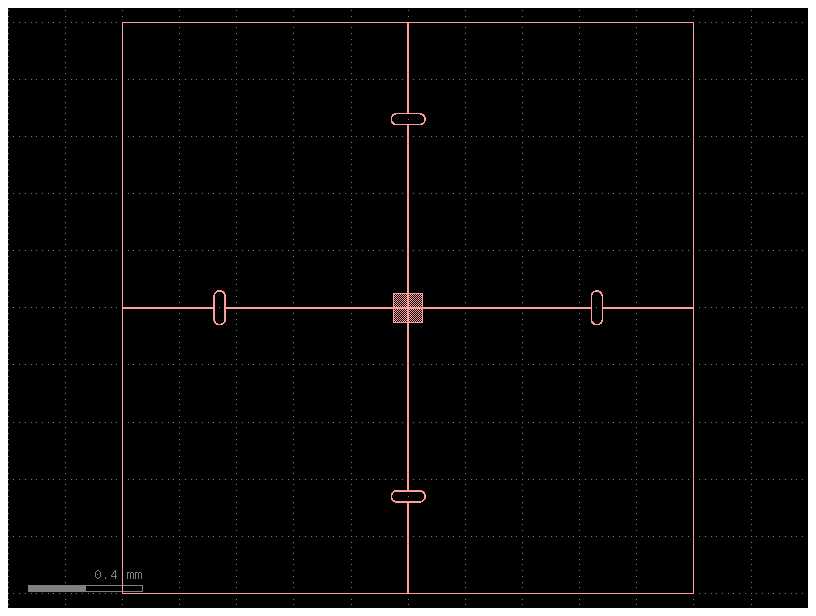

In [ ]:
@gf.cell
def make_pattern_with_frame_for_simulation(
    square_size=2100,
    beam_width=35,
    layer=(1, 0),
    center_rect_size=100,
):
    """
    Positive pattern for simulation:
    4 rotated patterns + center rectangle + outer frame.
    No boolean subtraction.
    """

    c = gf.Component()

    # ============================================================
    # 1. Four rotated patterns + center rectangle
    # ============================================================
    pattern = make_pattern(
        square_size=square_size,
        beam_width=beam_width,
        layer=layer,
        center_rect_size=center_rect_size,
    )

    pattern_ref = c << pattern

    # ============================================================
    # 2. Outer frame
    # ============================================================
    frame_width = beam_width
    frame_size = square_size

    # Bottom frame
    bottom = c << gf.components.rectangle(
        size=(frame_size, frame_width),
        layer=layer,
    )
    bottom.move(
        (
            -frame_size / 2,
            -frame_size / 2,
        )
    )

    # Top frame
    top = c << gf.components.rectangle(
        size=(frame_size, frame_width),
        layer=layer,
    )
    top.move(
        (
            -frame_size / 2,
            frame_size / 2 - frame_width,
        )
    )

    # Left frame
    left = c << gf.components.rectangle(
        size=(frame_width, frame_size),
        layer=layer,
    )
    left.move(
        (
            -frame_size / 2,
            -frame_size / 2,
        )
    )

    # Right frame
    right = c << gf.components.rectangle(
        size=(frame_width, frame_size),
        layer=layer,
    )
    right.move(
        (
            frame_size / 2 - frame_width,
            -frame_size / 2,
        )
    )

    # ============================================================
    # 3. Move lower-left corner to (0, 0)
    # ============================================================
    result = gf.Component()
    ref = result << c
    ref.move(
        origin=(c.xmin, c.ymin),
        destination=(0, 0),
    )

    return result

# ============================================================
# Run: pattern + outer frame for COMSOL
# ============================================================
gf.clear_cache()

pattern_sim = make_pattern_with_frame_for_simulation(
    square_size=2000,
    beam_width=2,
    layer=(1, 0),
    center_rect_size=100,
)

pattern_sim.plot()
pattern_sim.show()

pattern_sim.write_gds("pattern_with_frame_for_comsol.gds")

print("xmin =", pattern_sim.xmin)
print("ymin =", pattern_sim.ymin)
print("xmax =", pattern_sim.xmax)
print("ymax =", pattern_sim.ymax)